In [40]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm import tqdm

In [41]:
df_spot=pd.read_csv("../options_dashboard/nifty_underlying.csv")

In [42]:
df_spot

,open,high,low,close,volume,datetime
0,12204.8999,12216.2000,12201.5000,12215.2000,0.0,2020-01-01 09:15:00
1,12214.8999,12216.3999,12205.0000,12206.2999,0.0,2020-01-01 09:16:00
2,12206.5000,12207.5000,12202.5000,12203.5000,0.0,2020-01-01 09:17:00
3,12203.0000,12208.7000,12201.2000,12208.2999,0.0,2020-01-01 09:18:00
4,12208.2999,12213.3999,12207.3999,12211.5000,0.0,2020-01-01 09:19:00
...,...,...,...,...,...,...
505320,25129.9500,25132.7500,25127.8000,25129.3500,0.0,2025-06-11 15:25:00
505321,25130.6000,25133.4000,25129.3500,25131.4000,0.0,2025-06-11 15:26:00
505322,25130.9500,25132.8000,25125.8000,25126.6000,0.0,2025-06-11 15:27:00
505323,25128.3000,25131.6000,25126.9000,25127.9500,0.0,2025-06-11 15:28:00


In [43]:
df_spot["datetime"]=pd.to_datetime(df_spot["datetime"])
df_spot.info()


<class 'pandas.DataFrame'>
RangeIndex: 505325 entries, 0 to 505324
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   open      505325 non-null  float64       
 1   high      505325 non-null  float64       
 2   low       505325 non-null  float64       
 3   close     505325 non-null  float64       
 4   volume    505325 non-null  float64       
 5   datetime  505325 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(5)
memory usage: 23.1 MB


In [44]:
df_spot.set_index("datetime")

,open,high,low,close,volume
datetime,,,,,
2020-01-01 09:15:00,12204.8999,12216.2000,12201.5000,12215.2000,0.0
2020-01-01 09:16:00,12214.8999,12216.3999,12205.0000,12206.2999,0.0
2020-01-01 09:17:00,12206.5000,12207.5000,12202.5000,12203.5000,0.0
2020-01-01 09:18:00,12203.0000,12208.7000,12201.2000,12208.2999,0.0
2020-01-01 09:19:00,12208.2999,12213.3999,12207.3999,12211.5000,0.0
...,...,...,...,...,...
2025-06-11 15:25:00,25129.9500,25132.7500,25127.8000,25129.3500,0.0
2025-06-11 15:26:00,25130.6000,25133.4000,25129.3500,25131.4000,0.0
2025-06-11 15:27:00,25130.9500,25132.8000,25125.8000,25126.6000,0.0


In [45]:
df_spot_dec = df_spot[
    (df_spot["datetime"] >= "2023-12-01") & (df_spot["datetime"] <= "2023-12-31")
]
df_spot_dec

,open,high,low,close,volume,datetime
364112,20194.10,20216.75,20183.70,20212.45,0.0,2023-12-01 09:15:00
364113,20208.75,20212.45,20199.70,20208.55,0.0,2023-12-01 09:16:00
364114,20209.00,20215.05,20202.95,20215.05,0.0,2023-12-01 09:17:00
364115,20216.40,20225.30,20215.25,20223.10,0.0,2023-12-01 09:18:00
364116,20221.35,20225.75,20219.10,20220.10,0.0,2023-12-01 09:19:00
...,...,...,...,...,...,...
371607,21723.35,21729.15,21722.50,21727.25,0.0,2023-12-29 15:25:00
371608,21726.00,21731.45,21725.10,21730.90,0.0,2023-12-29 15:26:00
371609,21731.20,21738.40,21729.35,21736.30,0.0,2023-12-29 15:27:00
371610,21736.40,21739.35,21729.65,21734.65,0.0,2023-12-29 15:28:00


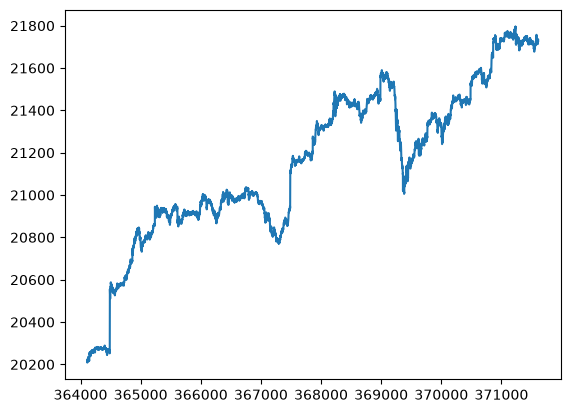

In [46]:
plt.plot(df_spot_dec["close"])

In [47]:
def compute_indicators(df):
    df['rolling_mean'] = df['close'].rolling(20).mean()
    df['rolling_std'] = df['close'].rolling(20).std()
    df['bb_width'] = (4 * df['rolling_std']) / df['rolling_mean']

    return df

In [48]:
df_spot=compute_indicators(df_spot_dec)


In [49]:
df_spot['BBW_Threshold'] = df_spot['bb_width'].rolling(window=20).quantile(0.2)

In [50]:
df_spot['Time'] = df_spot['datetime'].dt.time
df_spot['Signal'] = ((df_spot['bb_width'] < df_spot['BBW_Threshold'])).astype(int)
df_spot.dropna(inplace=True)
def round_to_strike(price, interval=100):
    return int(int(price / interval) * interval)

# Apply only on signal rows, NaN otherwise
df_spot['ATM_Strike'] = np.where(
    df_spot['Signal'] == 1,
    df_spot['close'].apply(lambda x: round_to_strike(x, 100)),
    np.nan
)

In [51]:
df_spot['ATM_Strike'] = df_spot['ATM_Strike'].ffill()
df_spot.dropna(inplace=True)
len(df_spot)

7447

In [52]:
def round_to_strike(price, interval=100):
    return int(int(price / interval) * interval)

# Apply only on signal rows, NaN otherwise
df_spot['ATM_Strike'] = np.where(
    df_spot['Signal'] == 1,
    df_spot['close'].apply(lambda x: round_to_strike(x, 100)),
    np.nan
)

In [53]:
df_spot['ATM_Strike'] = df_spot['ATM_Strike'].ffill()

In [54]:
df_spot.dropna(inplace=True)
len(df_spot)

7447

In [55]:
month_map = {
    1: '01Jan', 2: '02Feb', 3: '03Mar', 4: '04Apr',
    5: '05May', 6: '06Jun', 7: '07Jul', 8: '08Aug',
    9: '09Sep', 10: '10Oct', 11: '11Nov', 12: '12Dec'
}
from tqdm import tqdm

In [56]:
#  Config
expiry_map = {
    "01Jan": "2023-01-25",
    "02Feb": "2023-02-23",
    "03Mar": "2023-03-29",
    "04Apr": "2023-04-27",
    "05May": "2023-05-25",
    "06Jun": "2023-06-28",
    "07Jul": "2023-07-27",
    "08Aug": "2023-08-31",
    "09Sep": "2023-09-28",
    "10Oct": "2023-10-26",
    "11Nov": "2023-11-30",
    "12Dec": "2023-12-28"
}

month_map = {
    1: '01Jan', 2: '02Feb', 3: '03Mar', 4: '04Apr',
    5: '05May', 6: '06Jun', 7: '07Jul', 8: '08Aug',
    9: '09Sep', 10: '10Oct', 11: '11Nov', 12: '12Dec'
}

def round_to_strike(price, interval=100):
    return int(round(price / interval) * interval)


In [57]:
#  Initialize Variables
nifty_df = df_spot  # This has columns: datetime, close, Signal
base_path = "../options_dashboard"
initial_capital = 100000
capital = initial_capital
capital_per_trade = 10000
lot_size = 50

pnl_list = []
capital_series = []
win_trades = 0
trade_log = []
option_cache = {}
in_trade = False

# Trade state variables
current_trade = {
    "signal_time": None,
    "strike": None,
    "expiry_date_str": None,
    "ce_price_entry": None,
    "pe_price_entry": None,
    "entry_nifty": None,
    "num_lots": None,
    "entry_cost": None,
    "ce_df": None,
    "pe_df": None
}

capital_list=[]

In [58]:
import os

In [59]:
for i, row in tqdm(nifty_df.iterrows(), total=len(nifty_df)):
    current_time = row["datetime"]
    capital_list.append(capital)

    if row.get("Signal") and not in_trade:
        try:
            signal_time = pd.to_datetime(row["datetime"])
            atm_strike = round_to_strike(row["close"])
            delta = 100
            lower_strike = atm_strike - delta
            upper_strike = atm_strike + delta

            month_key = month_map[signal_time.month]
            expiry_date_str = expiry_map[month_key]
            expiry_dt = pd.to_datetime("2023-12-28") 
            expiry_folder = "12Dec-Nifty"

            atm_file = f"{atm_strike}_call_2023-12-28.csv"
            lower_file = f"{lower_strike}_call_2023-12-28.csv"
            upper_file = f"{upper_strike}_call_2023-12-28.csv"

            atm_path = os.path.join(base_path, expiry_folder, atm_file)
            lower_path = os.path.join(base_path, expiry_folder, lower_file)
            upper_path = os.path.join(base_path, expiry_folder, upper_file)

            for path in [atm_path, lower_path, upper_path]:
                if path not in option_cache:
                    df = pd.read_csv(path)
                    df['datetime'] = pd.to_datetime(df['datetime'])
                    option_cache[path] = df

            atm_df = option_cache[atm_path]
            lower_df = option_cache[lower_path]
            upper_df = option_cache[upper_path]

            atm_entry = atm_df[atm_df["datetime"] == signal_time]
            lower_entry = lower_df[lower_df["datetime"] == signal_time]
            upper_entry = upper_df[upper_df["datetime"] == signal_time]

            if atm_entry.empty or lower_entry.empty or upper_entry.empty:
                continue

            atm_price = atm_entry["close"].values[0]
            lower_price = lower_entry["close"].values[0]
            upper_price = upper_entry["close"].values[0]

            entry_cost = (lower_price + upper_price - 2 * atm_price) * lot_size
            num_lots = int(capital_per_trade // abs(entry_cost))
            if num_lots == 0:
                continue

            trade_cost = abs(entry_cost) * num_lots

            current_trade = {
                "signal_time": signal_time,
                "atm_strike": atm_strike,
                "lower_strike": lower_strike,
                "upper_strike": upper_strike,
                "atm_price": atm_price,
                "lower_price": lower_price,
                "upper_price": upper_price,
                "entry_nifty": row["close"],
                "num_lots": num_lots,
                "entry_cost": trade_cost,
                "expiry_date_str": expiry_date_str,
                "atm_df": atm_df,
                "lower_df": lower_df,
                "upper_df": upper_df
            }
            in_trade = True
            print(f"Entered butterfly at {signal_time}: ATM {atm_strike}, Lots {num_lots}")

        except Exception as e:
            print(f"Butterfly entry failed: {str(e)}")
            continue

    if in_trade:
        expiry_date = pd.to_datetime(current_trade["expiry_date_str"]).date()

        if current_time.date() == expiry_date and current_time.time() >= pd.Timestamp("15:15:00").time():
            try:
                atm_exit = current_trade["atm_df"][
                    (current_trade["atm_df"]["datetime"].dt.date == expiry_date) &
                    (current_trade["atm_df"]["datetime"].dt.time == pd.Timestamp("15:15:00").time())]
                lower_exit = current_trade["lower_df"][
                    (current_trade["lower_df"]["datetime"].dt.date == expiry_date) &
                    (current_trade["lower_df"]["datetime"].dt.time == pd.Timestamp("15:15:00").time())]
                upper_exit = current_trade["upper_df"][
                    (current_trade["upper_df"]["datetime"].dt.date == expiry_date) &
                    (current_trade["upper_df"]["datetime"].dt.time == pd.Timestamp("15:15:00").time())]

                if atm_exit.empty or lower_exit.empty or upper_exit.empty:
                    raise ValueError("Missing expiry price")

                atm_price_exit = atm_exit["close"].values[0]
                lower_price_exit = lower_exit["close"].values[0]
                upper_price_exit = upper_exit["close"].values[0]
                exit_reason = "Expiry"
            except:
                atm_price_exit = current_trade["atm_df"]["close"].iloc[-1]
                lower_price_exit = current_trade["lower_df"]["close"].iloc[-1]
                upper_price_exit = current_trade["upper_df"]["close"].iloc[-1]
                exit_reason = "Expiry (Fallback)"
        else:
            try:
                atm_now = current_trade["atm_df"][current_trade["atm_df"]["datetime"] == current_time]["close"].values[0]
                lower_now = current_trade["lower_df"][current_trade["lower_df"]["datetime"] == current_time]["close"].values[0]
                upper_now = current_trade["upper_df"][current_trade["upper_df"]["datetime"] == current_time]["close"].values[0]

                current_value = (lower_now + upper_now - 2 * atm_now) * lot_size * current_trade["num_lots"]
                return_pct = (current_value - current_trade["entry_cost"]) / current_trade["entry_cost"]

                if return_pct >= 1.0:
                    atm_price_exit = atm_now
                    lower_price_exit = lower_now
                    upper_price_exit = upper_now
                    exit_reason = "Profit Target"
                else:
                    continue
            except:
                continue

        exit_value = (lower_price_exit + upper_price_exit - 2 * atm_price_exit) * lot_size * current_trade["num_lots"]
        trade_pnl = exit_value - current_trade["entry_cost"]
        capital += trade_pnl
        pnl_list.append(trade_pnl)
        if trade_pnl > 0:
            win_trades += 1

        trade_log.append({
            "entry_time": current_trade["signal_time"],
            "exit_time": current_time,
            "exit_reason": exit_reason,
            "atm_strike": current_trade["atm_strike"],
            "lower_strike": current_trade["lower_strike"],
            "upper_strike": current_trade["upper_strike"],
            "entry_nifty": current_trade["entry_nifty"],
            "exit_nifty": row["close"],
            "atm_entry": current_trade["atm_price"],
            "lower_entry": current_trade["lower_price"],
            "upper_entry": current_trade["upper_price"],
            "atm_exit": atm_price_exit,
            "lower_exit": lower_price_exit,
            "upper_exit": upper_price_exit,
            "num_lots": current_trade["num_lots"],
            "pnl": trade_pnl,
            "capital": capital
        })
        print(f"Exited butterfly: {exit_reason} | P&L: {trade_pnl:.2f}")
        in_trade = False


  3%|▎         | 256/7447 [00:00<00:05, 1297.49it/s]

Entered butterfly at 2023-12-01 10:08:00: ATM 20200, Lots 33


  7%|▋         | 530/7447 [00:00<00:05, 1340.05it/s]

Exited butterfly: Profit Target | P&L: 19635.00
Entered butterfly at 2023-12-04 09:33:00: ATM 20600, Lots 24


 17%|█▋        | 1252/7447 [00:00<00:04, 1383.18it/s]

...

Exited butterfly: Profit Target | P&L: 11732.50
Entered butterfly at 2023-12-20 13:46:00: ATM 21400, Lots 49
Exited butterfly: Profit Target | P&L: 21192.50
Entered butterfly at 2023-12-20 13:48:00: ATM 21400, Lots 35
Exited butterfly: Profit Target | P&L: 24325.00
Entered butterfly at 2023-12-20 13:55:00: ATM 21400, Lots 25
Exited butterfly: Profit Target | P&L: 14500.00
Entered butterfly at 2023-12-20 14:19:00: ATM 21300, Lots 24
Exited butterfly: Profit Target | P&L: 13440.00
Entered butterfly at 2023-12-20 14:53:00: ATM 21200, Lots 14


 92%|█████████▏| 6819/7447 [00:04<00:00, 1382.50it/s]

Exited butterfly: Profit Target | P&L: 10920.00
Entered butterfly at 2023-12-27 15:20:00: ATM 21700, Lots 8


100%|██████████| 7447/7447 [00:05<00:00, 1461.31it/s]

Exited butterfly: Profit Target | P&L: 10500.00
Entered butterfly at 2023-12-28 15:16:00: ATM 21800, Lots 2
Exited butterfly: Expiry | P&L: -80.00
Entered butterfly at 2023-12-28 15:17:00: ATM 21800, Lots 2
Exited butterfly: Expiry | P&L: 100.00
Entered butterfly at 2023-12-28 15:18:00: ATM 21800, Lots 2
Exited butterfly: Expiry | P&L: 125.00
Entered butterfly at 2023-12-28 15:19:00: ATM 21800, Lots 2
Exited butterfly: Expiry | P&L: -40.00
Entered butterfly at 2023-12-28 15:20:00: ATM 21800, Lots 2
Exited butterfly: Expiry | P&L: -80.00
Entered butterfly at 2023-12-28 15:21:00: ATM 21800, Lots 2
Exited butterfly: Expiry | P&L: -380.00
Entered butterfly at 2023-12-28 15:22:00: ATM 21800, Lots 2
Exited butterfly: Expiry | P&L: -415.00
Entered butterfly at 2023-12-28 15:23:00: ATM 21800, Lots 2
Exited butterfly: Expiry | P&L: -365.00
Entered butterfly at 2023-12-28 15:24:00: ATM 21800, Lots 2
Exited butterfly: Expiry | P&L: -360.00


In [60]:
# ----------------------------- Results -----------------------------
print(f"\nBacktest Complete")
print(f"Total Trades: {len(trade_log)}")
print(f"Winning Trades: {win_trades}")
print(f"Win Rate: {win_trades/len(trade_log)*100:.2f}%" if trade_log else "No trades")
print(f"Final Capital: {capital:.2f}")
print(f"Total P&L: {capital - initial_capital:.2f}")

# Convert log to DataFrame
df = pd.DataFrame(trade_log)


Backtest Complete
Total Trades: 22
Winning Trades: 15
Win Rate: 68.18%
Final Capital: 459070.00
Total P&L: 359070.00


In [61]:
import pandas as pd
import numpy as np

df['exit_time'] = pd.to_datetime(df['exit_time'])

# Compute equity curve
df['cumulative_pnl'] = df['pnl'].cumsum()
df['equity_curve'] = df['capital'].iloc[0] + df['cumulative_pnl']


In [62]:
df['rolling_max'] = df['equity_curve'].cummax()
df['drawdown'] = df['equity_curve'] - df['rolling_max']
df['drawdown_pct'] = df['drawdown'] / df['rolling_max']

max_drawdown = df['drawdown_pct'].min()
print(f"Max Drawdown: {max_drawdown:.2%}")


Max Drawdown: -0.34%


In [63]:
df['log_equity'] = np.log(df['equity_curve'])
df['log_return'] = df['log_equity'].diff()
df = df.dropna()


In [64]:
risk_free_rate_annual = 0.06
minutes_per_year = 252 * 390
rf_per_minute = np.log(1 + risk_free_rate_annual) / minutes_per_year

# Excess returns
df['excess_return'] = df['log_return'] - rf_per_minute

# Sharpe Ratio
mean_excess_return = df['excess_return'].mean()
std_dev_return = df['log_return'].std()

sharpe_ratio = (mean_excess_return / std_dev_return) * np.sqrt(minutes_per_year)

print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


Annualized Sharpe Ratio: 116.04


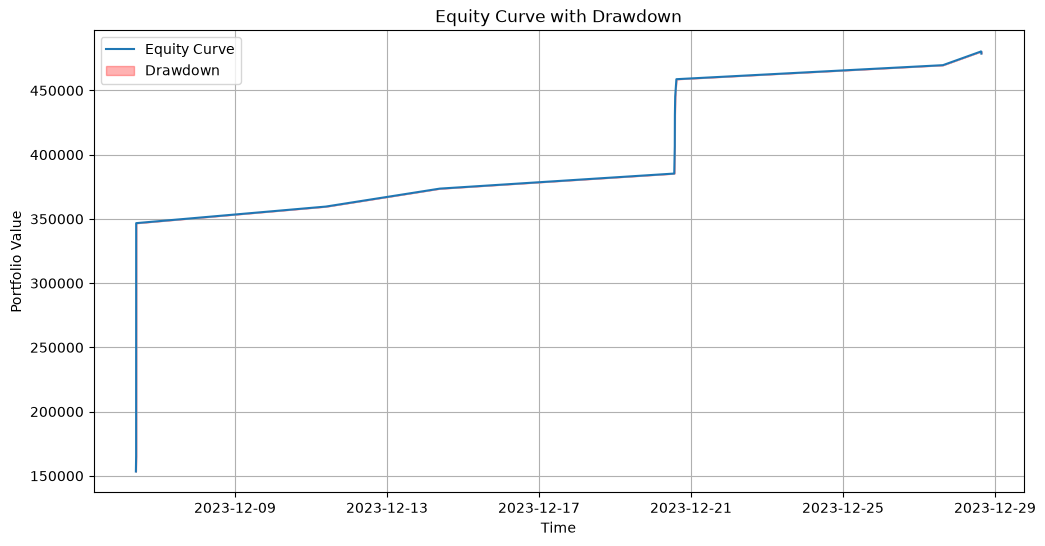

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['exit_time'], df['equity_curve'], label='Equity Curve')
plt.fill_between(df['exit_time'], df['rolling_max'], df['equity_curve'], color='red', alpha=0.3, label='Drawdown')
plt.legend()
plt.title("Equity Curve with Drawdown")
plt.xlabel("Time")
plt.ylabel("Portfolio Value")
plt.grid()
plt.show()
